In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc tệp CSV (thay 'your_file.csv' bằng tên tệp của bạn)
file_path = 'orders_with_2_items.csv'  # Đường dẫn đến tệp của bạn
data = pd.read_csv(file_path)

# Kiểm tra số lượng hàng
num_rows = data.shape[0]
print(f"Số lượng hàng trong tệp: {num_rows}")

Số lượng hàng trong tệp: 8291


In [3]:
import re

def extract_features(order):
    o = order.lower()
    # đếm tổng số món
    num_items = sum(int(m.group(1)) for m in re.finditer(r'(\d+)\s*x', o))
    return {
        'num_items': num_items,
        'num_chicken': int('chicken' in o),
        'num_rice': int('rice' in o),
        'num_fries': int('fries' in o or 'krispers' in o),
        'num_paneer': int('paneer' in o),
        'num_drink': int(any(drink in o for drink in ['ale','cola','tea','juice'])),
        'has_grilled': int('grilled' in o),
        'has_fried': int('fried' in o),
        'has_bbq': int('bbq' in o),
        'has_boiled': int('soup' in o or 'pho' in o),
        'has_peri_peri': int('peri peri' in o),
        'has_angara': int('angara' in o),
        'has_jamaican': int('jamaican' in o),
        'has_smoky': int('smoky' in o),
        'has_salad': int('salad' in o),
        'has_saucy': int('saucy' in o),
        'has_bone_in': int('bone in' in o),
    }

features_df = data['Items in order'].apply(extract_features).apply(pd.Series)

attribute_counts = features_df.sum()

# In ra số lần xuất hiện của mỗi thuộc tính
print("Số lần xuất hiện của mỗi thuộc tính:")
for attribute, count in attribute_counts.items():
    print(f"{attribute}: {count}")


Số lần xuất hiện của mỗi thuộc tính:
num_items: 16582
num_chicken: 3990
num_rice: 85
num_fries: 981
num_paneer: 1549
num_drink: 96
has_grilled: 2283
has_fried: 806
has_bbq: 542
has_boiled: 0
has_peri_peri: 1596
has_angara: 861
has_jamaican: 1574
has_smoky: 542
has_salad: 0
has_saucy: 66
has_bone_in: 1316


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

def load_and_extract(path):
    df = pd.read_csv(path)
    feats = df['Items in order'].apply(extract_features).apply(pd.Series)
    return feats

features_3 = load_and_extract('orders_with_2_items.csv')

# Chuẩn hóa vì các feature có scale khác nhau
scaler = StandardScaler()
X_3 = scaler.fit_transform(features_3)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# tìm K tốt nhất với Silhouette
best_k, best_score = None, -1
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42).fit(X_3)
    score = silhouette_score(X_3, km.labels_)
    if score > best_score:
        best_k, best_score = k, score

# chạy KMeans với K tối ưu
km_final = KMeans(n_clusters=best_k, random_state=42).fit(X_3)
labels_3 = km_final.labels_

# In ra kết quả phân cụm
print(f"Số cụm tối ưu: {best_k}")
print("Số lượng điểm dữ liệu trong mỗi cụm:")
unique, counts = np.unique(labels_3, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cụm {cluster}: {count} điểm dữ liệu")

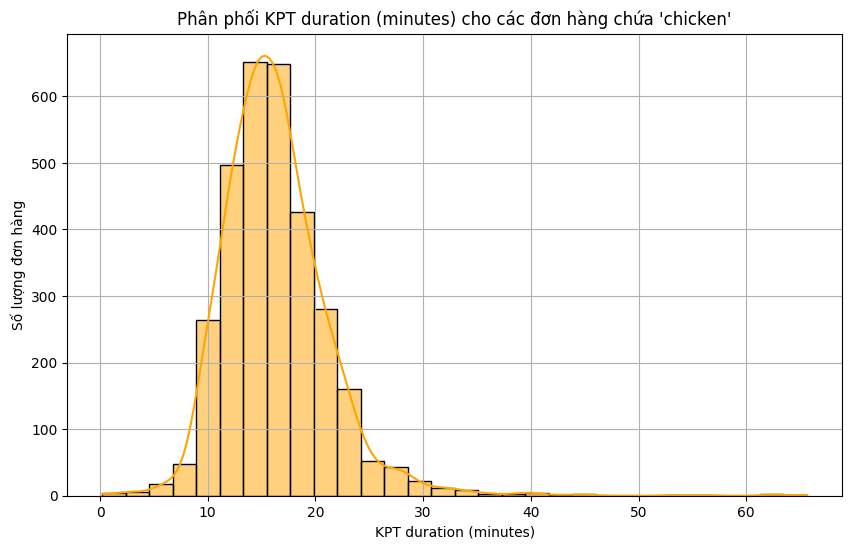

📊 Thống kê KPT duration (minutes) cho đơn hàng chứa 'chicken':
count    3156.000000
mean       16.312788
std         5.010348
min         0.220000
25%        13.130000
50%        15.800000
75%        18.730000
max        65.630000
Name: KPT duration (minutes), dtype: float64
🍗 Top 10 món 'chicken' phổ biến:
clean_item
bone in jamaican grilled chicken     527
all about chicken pizza              413
jamaican chicken melt                242
bone in smoky bbq grilled chicken    198
fried chicken peri peri tender       147
bone in peri peri grilled chicken    144
grilled chicken jamaican tender      124
bone in kabuli grilled chicken       121
bone in angara grilled chicken       116
fried chicken classic tender         109
Name: count, dtype: int64


/var/folders/93/jzhc9xv925g12nywcpx4b7b80000gn/T/ipykernel_19919/1392757433.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_chicken['clean_item'] = df_chicken['Items in order'].apply(extract_item)


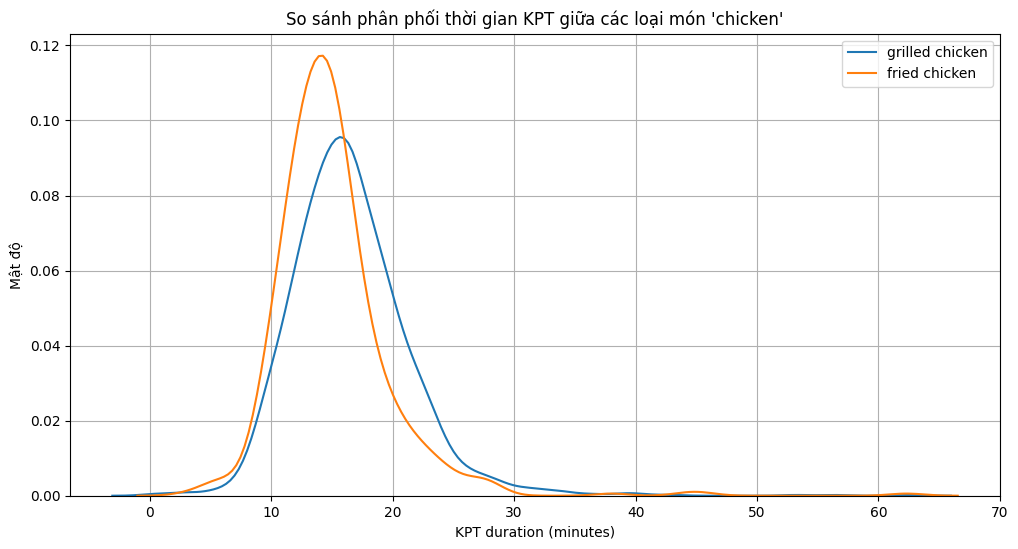

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file
df = pd.read_csv("orders_with_1_items.csv")

# Lọc các đơn có chứa 'chicken'
df_chicken = df[df['Items in order'].str.contains('chicken', case=False, na=False)]

# Vẽ histogram nếu có cột KPT
if 'KPT duration (minutes)' in df_chicken.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_chicken['KPT duration (minutes)'], bins=30, kde=True, color='orange')
    plt.title("Phân phối KPT duration (minutes) cho các đơn hàng chứa 'chicken'")
    plt.xlabel("KPT duration (minutes)")
    plt.ylabel("Số lượng đơn hàng")
    plt.grid(True)
    plt.show()
else:
    print("Không tìm thấy cột 'KPT duration (minutes)' trong dữ liệu.")


if 'KPT duration (minutes)' in df_chicken.columns:
    print("📊 Thống kê KPT duration (minutes) cho đơn hàng chứa 'chicken':")
    print(df_chicken['KPT duration (minutes)'].describe())


from collections import Counter
import re

# Trích từng món ăn từ đơn hàng
def extract_item(order):
    order = re.sub(r"\d+\s*x\s*", "", str(order))  # bỏ số lượng
    return order.strip().lower()

df_chicken['clean_item'] = df_chicken['Items in order'].apply(extract_item)
top_chicken_items = df_chicken['clean_item'].value_counts().head(10)

print("🍗 Top 10 món 'chicken' phổ biến:")
print(top_chicken_items)

plt.figure(figsize=(12, 6))
chicken_types = ['grilled chicken', 'fried chicken', 'tandoori chicken']

for ctype in chicken_types:
    subset = df_chicken[df_chicken['clean_item'].str.contains(ctype)]
    sns.kdeplot(subset['KPT duration (minutes)'], label=ctype)

plt.title("So sánh phân phối thời gian KPT giữa các loại món 'chicken'")
plt.xlabel("KPT duration (minutes)")
plt.ylabel("Mật độ")
plt.legend()
plt.grid(True)
plt.show()



In [5]:
import pandas as pd
from collections import Counter
import re

# Đọc dữ liệu
df = pd.read_csv("orders_with_1_items.csv")

# Hàm tách từng món ăn
def extract_items(order_text):
    order_text = re.sub(r"[^a-zA-Z0-9 x]", "", str(order_text))  # làm sạch ký tự đặc biệt
    items = re.split(r"\d+\s*x\s*", order_text.lower())  # tách theo "1 x", "2 x", ...
    return [item.strip() for item in items if item.strip()]

# Áp dụng để tách món
df['items_list'] = df['Items in order'].apply(extract_items)

# Đếm toàn bộ món xuất hiện
all_items = [item for sublist in df['items_list'] for item in sublist]
item_counts = Counter(all_items)

# Chuyển thành DataFrame để xem top
df_item_counts = pd.DataFrame(item_counts.items(), columns=['item', 'count'])
df_item_counts = df_item_counts.sort_values(by='count', ascending=False)

# In top 10 món ăn phổ biến
print(df_item_counts.head(10))


                                item  count
26                    bageecha pizza    803
3   bone in jamaican grilled chicken    538
28           all about chicken pizza    413
33                  margherita pizza    368
32        chilli cheese garlic bread    312
38              makhani paneer pizza    310
34             jamaican chicken melt    244
37              tripple cheese pizza    232
40       murgh amritsari seekh pizza    226
10                      animal fries    206
